# Machine Learning (CMP3751M/CMP9772M) - Assessment 02

Through the following notebook, you will be analysing a dataset and fitting a classification model to this dataset.

The assessment is structured as follows:
- [Dataset description](#Dataset-description)
- [Loading the dataset](#Loading-the-dataset)
- [Simple classification model](#Simple-classification-model)
    - [Creating a training and testing set](#Creating-a-training-and-testing-set)
    - [Training a classifier](#Training-a-classifier)
- [Improved evaluation strategy](#Improved-evaluation-strategy)
- [Different models and parameter search](#Different-models-and-parameter-search)
- [Ensembles](#Ensembles)
- [Final model evaluation](#Final-model-evaluation)
- [References](#References)

**Notes:**
- Any discussion not supported by your implementation will not be awarded marks.
- **Do not modify** any code provided as a **TESTING CELL**.
- Make sure to **fix all the random seeds** in any parts of your solution, so it can be reproduced exactly.
- The notebook, as provided, runs without errors (without solving the assessment). Make sure that the solution, or the partial solution, you hand in, also **runs without errors** on the data provided. If you have a partial solution causing errors which you would like to show, please include it as a comment.
- Take care to include references to any external sources used. Check the [References](#References) section, the below cell, and the exambles through the assessment text for examples of how to do this.


In [1]:
# Remember to reference your sources! Check the bottom of the file, and examples used in the text of the assessment,
# for including references to papers and software in your textual answers

# Also add a reference in your solution cell before defining a class/function/method, eg.:

# This code is a modified and extended version of [3]
# OR
# This code is a modified and extended version of https://stackoverflow.com/q/522563/884412
##############
## THE CODE ##
##############

## Dataset description

The the assessment will be done on the dataset containing only numerical features describing the size and shape features of different varieties of dry beans [1]. (The dataset for this assessment has been adapted from the full dataset which can be found [here](https://www.muratkoklu.com/datasets/) [2]), shared in the public domain by the author).

Each sample describes the measurements of a bean of a single variety, and consists of following 16 features:

| Feature Name      | Value | Description |
| :---------------- | :----- | ----------- |
| `Area`       | `float` | Area of the bean in pixels. |
| `Perimeter` | `float` | Bean circumference is defined as the length of its border. |
| `MajorAxisLength` | `float` | The distance between the ends of the longest line that can be drawn from a bean. |
| `MinorAxisLength` | `float` | The longest line that can be drawn from the bean while standing perpendicular to the main axis. |
| `AspectRatio` | `float` | The ratio between the major and minor axis length. |
| `Eccentricity` | `float` | Eccentricity of the ellipse having the same moments as the region. |
| `ConvexArea` | `int` | Number of pixels in the smallest convex polygon that can contain the area of a bean seed. |
| `EquivDiameter` | `float` | The diameter of a circle having the same area as a bean seed area. |
| `Extent` | `float` | The ratio of the pixels in the bounding box to the bean area. |
| `Solidity` | `float` | Also known as convexity. The ratio of the pixels in the convex shell to those found in beans. |
| `Roundness`| `float` | Measures the roundness of an object. |
| `Compactness` | `float` | An alternative measure of object roundness. |
| `ShapeFactor1` | `float` | Shape features according to [4] |
| `ShapeFactor2` | `float` | Shape features according to [4] |
| `ShapeFactor3` | `float` | Shape features according to [4] |
| `ShapeFactor4` | `float` | Shape features according to [4] |



The goal for the assessment is to predict the variety of bean, listed in the last column, which provides a classification for each sample:

| Class      | Value | Description |
| :---------------- | :----- | ----------- |
| `Class`  | `string`: class designation | The variety of dry bean. |


## Loading the dataset

The dataset is given in _beans.csv_ file provided on Blackboard. **Load the dataset into two [`numpy.array`](https://numpy.org/doc/stable/reference/generated/numpy.array.html)s.**: 
- The variable `X` should be a 2D [`numpy.array`](https://numpy.org/doc/stable/reference/generated/numpy.array.html) containing all the samples and their features from the dataset, one sample per row. 
- The variable `y` should be a 1D [`numpy.array`](https://numpy.org/doc/stable/reference/generated/numpy.array.html) containing the ground truth (class) as given in the `'Class'` field of the _.csv_ file.
- _Note_: The class in the `'Class'` column is given as a string. Make sure you encode the class as an integer number in your ground truth `y`.
- _Note_: You should make sure that your code for loading the dataset is guided by the information about the dataset, and the dataset description you provide as your answer.

**Describe the dataset**. Provide a basic description of the dataset. How many samples are there in the dataset? How many distinct classes? What types of features describe the samples in the dataset? Are there any missing values in the dataset? (Make sure these are properly handled). 
- _Note_: Make sure all your answers are supported by your implementation. Answers not supported by your implementation will not score any marks.

Provide your code to _load the dataset_ and the code that will allow you to _describe the dataset_ in the **SOLUTION CELL**. Provide your description of the dataset in the **ANSWER CELL**. A correct solution should result in no errors when running the **TESTING CELL** provided.

**SOLUTION CELL**

In [1]:
import numpy as np
import pandas as pd

################################
#### ADD YOUR SOLUTION HERE ####
################################

######## replace this code #####
#read the .csv into pandas dataframe
df = pd.read_csv('beans.csv')

#print the descriptive information
print(f'The shape of the dataset is : {df.shape}\n')
print(df.describe())
print(f'\nThe sum of empty values is : {df.isnull().sum().sum()}\n')

#remove empty rows
df2 = df.dropna()
print(f'The sum of empty values after handling is : {df2.isnull().sum().sum()}\n')
print(f'The shape of the dataset is : {df2.shape}\n')
print(df2.describe())
print(df2.describe(include=[object]))

#factorize the string values of class into ints
y = pd.factorize(df2['Class'])

#store the data into np.arrays
X = np.array(df2.iloc[:,0:-1])
y = np.array(y[0])

#shows the class distribution
print(df2['Class'].value_counts())




The shape of the dataset is : (2900, 17)

                Area    Perimeter  MajorAxisLength  MinorAxisLength  \
count    2900.000000  2899.000000      2897.000000      2896.000000   
mean    50354.271379   829.850859       309.533459       198.349375   
std     28371.524477   209.558461        83.149712        44.009104   
min     20942.000000   530.683000       187.168635       135.173095   
25%     34407.500000   686.442000       248.514426       171.389930   
50%     41894.500000   765.979000       282.799354       189.098022   
75%     56238.250000   937.444000       363.493790       210.215658   
max    251432.000000  1921.685000       738.144502       450.926187   

       AspectRatio  Eccentricity     ConvexArea  EquivDiameter       Extent  \
count  2885.000000   2900.000000    2900.000000    2897.000000  2899.000000   
mean      1.558730      0.745825   51030.942414     246.537800     0.752603   
std       0.224354      0.085925   28817.507409      57.963479     0.046190   
mi

**TESTING CELL**

In [2]:
assert(len(X.shape) == 2)
assert(len(y.shape) == 1)
assert(X.shape[0] == y.shape[0])


**ANSWER CELL**

Dataset description-

From the code written above, it is clear that there are 2900 rows and 17 columns.
The dataset is a classification problem as the labels/ground truth (y) is categorical while the features inside the dataset (X) are continuous numerical values.
There are 16 features in the dataset.
This means there should be 2900 entries, however some have missing data. The total of number of empty cells is 38, leaving the new total number of entries at 2866 after removing all the rows with missing data.
There are 7 distinct classes in the dataset, using the include=[object] command within the describe function showed the only row that has string values as opposed to numeric values of the 16 other columns. The dataset has a moderate imbalance, Dermason has a total of 981 while Bombay has 99. That is almost a 10/1 imbalance. The second biggest class has 550 and the rest fall between 394 and 247 entries. This will warrant handling to ensure that a chosen model will not discriminate against the smallest class while favouring the 2 largest classes as they make up half of the dataset.
The value of y has been changed from a string name to a numeric value using the pd.factorize() function.


## Simple classification model

To get the feel for the dataset, the first step will be to build train a simple classification model for this dataset. Do this in two steps detailed below:
1. Set aside some data for training and for testing.
2. Train a simple classifier on this data.

### Creating a training and testing set

**Set aside 20\% of the data for testing, and use the remaining 80\% to train your model.** Make sure to fix any random seeds if you use any functions or methods relying on those, so your experiments are _fully repeatable_. Initialise the following variables:
- `X_train` should contain the features corresponding to your training data.
- `y_train` should contain the ground truth of your training data.
- `X_test` should contain the features corresponding to your testing data.
- `y_train` should contain the ground truth associated to your testing data.

_Note:_ No additional marks will be rewarded for implementing an advanced data splitting strategy on this task. The purpose of this task is to start working with the dataset by applying a simple approach; you will have the chance to implement more complex evaluation pipelines in a later task.

Provide your implementation in the **SOLUTION CELL (a)** below. A correct solution should result in no errors when running the **TESTING CELL** provided.

### Training a classifier

**Train a simple classifier,** (of your choosing) **with fixed parameters** on the dataset, and **calculate accuracy on the test set**.
- Define a function `model_accuracy(y_test, y_pred)` to compare the ground truth given in `y_test` to predictions given in `y_pred` and calculate accuracy.
- **Store the model** in the variable named `model`. For the model, you may chose any classifier with which you are familiar (e.g. K Nearest Neighbours), or implement your own classifier. Make sure you **train your model** using the _training data_ only (`X_train`, `y_train`).
- Use the model to **predict the classes of the data** in the testing set (`X_test`), and calculate the accuracy by comparing the predictions with the ground truth for the testing set (`y_test`). **Store the predictions** in a variable called `y_pred`.

_Note:_ Do not implement an advanced strategy to chose the parameters of your classifier here, as that will be a topic of a latter question.

_Note:_ If you implement your own classifier, make sure you implement it as a _class_ following the _sklearn_ standard for classifiers (i.e. make sure it implements the `fit(X, y)` method to train the model, and `predict(X)` method to use the trained model to predict the classes of provided samples.


**Discuss the advantages and shortcomings** of the evaluation strategy implemented through this task. Discuss both the data split used for evaluation and the choice of metric. Taking into account the information you know about the dataset, what kind of accuracy scores can you expect on this dataset from a good and bad performing model? Based on the information you have so far, comment on the performance of the model you have trained on the provided dataset.

Provide your implementation in the **SOLUTION CELL (b)** below. The **TESTING CELL** below should run without errors and will print the prediction of your model for the first sample in the test set, and the accuracy as calculated by your `model_accuracy` function. Provide your discussion in the **ANSWER CELL** below.

**SOLUTION CELL (a)**

In [3]:
from sklearn.model_selection import train_test_split



#random seed stored in var for future use if necessary
r_seed = 25
#split data to 20% tes, 80% train
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=r_seed)



**TESTING CELL**

In [4]:
assert(X_train.shape[0] == y_train.shape[0])
assert(X_test.shape[0] == y_test.shape[0])
assert(X_train.shape[1] == X_test.shape[1])

**SOLUTION CELL (b)**

In [5]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

def model_accuracy(y_test, y_pred):
    
    return accuracy_score(y_test,y_pred)
    


model = KNeighborsClassifier(n_neighbors=53)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)


**TESTING CELL**

In [6]:
print(model.predict(X_test[0].reshape(1,-1)))
print(model_accuracy(y_test, y_pred))

[6]
0.6480836236933798


**ANSWER CELL**


The Accuracy metric is not a very useful one for furhter improvements. It doesn't provide any information on where the model is wrong, how accurate it is with each class as well as what is skewing the data and which features have the biggest impact. While the accuracy metric is very quick and easy to use, and doesn't have much of a cost, it doesn't describe the performance. As discussed in the previous task, the dataset is imbalanced. 2 out of 7 classes make up over half of the dataset, accuracy will not provide any clues as to which classes are misidentified. For example, the model could get one or more classes completly wrong with no correct predictions but accuracy by itself will not show that. The accuracy metric will not show where the model is wrong, where it needs improving or truly how good it is at classifying the dataset due to imbalances. A model that would predict all entries as the biggest class would still have an accuracy of of over 33% (over half of the achieved accuracy).
With this dataset and the K value chosen has taken negligible amount of time to perform the classification and was still able to achieve an accuracy of 64.8%. While not enough to be a succesful model yet, it is most likely better than random and without any hyperparameter tuning, balancing the dataset or adding any weights to the predictors, this performance is reasonable. However further and better evaluation metrics need to be used to decide whether or not the model works correctly. The K value was simply selected by taking the square root of the amount of entries, as the starting point and an odd number to ensure that there are no 50/50 cases. Due to the fact that the dataset is imbalanced, either a better data splitting startegy needs to be employed and/or a balancing of the values should be considered. It is very likely that the model currently is skewed towards the top 2 classes and biases against the small class, therefore resulting in a model that predicts 1 or 2 classes pretty accurately, however does really poorly with the less populated classes and the entries adjacent to the big class. In summary, it's hard to tell how good the model is with just the accuracy metric as it could simply be labeling something as either one of two of the largest classes which would make it a failed model even though the accuracy metric will show ok performance.

## Improved evaluation strategy

After discussing the shortcomings of the simple evaluation strategy used in the previous task, you now have a chance to **propose a better evaluation strategy.** Make sure your chosen strategy **uses all the samples in the dataset** to report the result.
- **Implement a function** `evaluate_model(model, X, y)` to implement your proposed evaluation strategy. The function should evaluate the model given in `model` on the dataset given by `X` with ground truth given by `y`. Note that the function should be passed the _whole of the dataset_ (see **TESTING CELL** below) and should take care of any data splitting internally.
- If desired, you may add additional arguments to this function, as long as they have default values and the function runs correctly when called using those default values.
- The function should return no values, but instead print the results of the evaluation in a human-readable format.
- Include at least one summative metric (providing a single number, e.g. accuracy) and per-class metric (e.g. precision) calculated for every class. You are encouraged to select more than one metric of each type.

This function will be used to provide a better evaluation of the simple model with fixed parameters used in the previous task.

**Discuss your chosen evaluation strategy**, including both the data split and the evaluation metrics. Which data splitting strategy did you chose and why? Which metrics did you chose, and why? Briefly explain the chosen data splitting strategy. What additional information can your additional metrics provide beyond accuracy?

Provide your implementation of this function in the **SOLUTION CELL**. You may also include any additional evaluation calls you want to include in this code cell. The **TESTING CELL** will perform a basic evaluation of your `model` using the `evaluate_model` function implemented for this task. Provide your discussion in the **ANSWER CELL** below.

**SOLUTION CELL**

In [7]:
from sklearn.metrics import balanced_accuracy_score, f1_score, matthews_corrcoef, precision_recall_curve, classification_report
from sklearn.model_selection import StratifiedKFold
#data splitting to k-fold
skf = StratifiedKFold(n_splits=7)
skf.get_n_splits(X,y)




def evaluate_model(model, X, y):
    for train_index, test_index in skf.split(X, y):
        X_train_fold, X_test_fold = X[train_index], X[test_index]
        y_train_fold, y_test_fold = y[train_index], y[test_index]
    
    model.fit(X_train_fold,y_train_fold)
    y_pred = model.predict(X_test_fold)

    
    
    
    bas = balanced_accuracy_score(y_test_fold,y_pred)
    print(f'The balanced accuracy is {bas}')
    print(f'The classification report is: {classification_report(y_pred,y_test_fold)}')
    
    
    

**TESTING CELL**

In [8]:
evaluate_model(model, X, y)

The balanced accuracy is 0.6134519954581774
The classification report is:               precision    recall  f1-score   support

           0       0.11      0.27      0.16        15
           1       1.00      1.00      1.00        14
           2       0.88      0.58      0.70        65
           3       0.94      0.78      0.85       170
           4       0.50      0.57      0.53        37
           5       0.02      0.17      0.03         6
           6       0.84      0.65      0.73       102

    accuracy                           0.67       409
   macro avg       0.61      0.57      0.57       409
weighted avg       0.82      0.67      0.74       409



**ANSWER CELL**

###Mention if the classifier is better than  random etc.
#amazing performance on one of the classes at 1, terrible performance at 2 classes, fair on 3 and ok at 1

The first metric to address is accuracy. While it is a simple metric and gives a hint as to how the model did overall, it's not very useful when the dataset has multiple classes and is imbalanced as it doesn't take into account performance of individual classes. The proposed evaluation strategy instead will use the balanced accuracy in addition to regular accuracy. It's more suitable for this dataset as it returns a mean of sensitivity and specificity, which is more appropriate in case of an imbalance in the dataset.
The class-specific metrics chosen are precision, recall and f-1 score. These will show the precision and recall, which show how good the model is at identifying relevant points. Another metric used is the f-1 score, this is the harmonious mean between precision and recall. It is the comparison between these 2 metrics and as such maximises them both.

The chosen strategy for data splitting is stratified k-fold. The dataset is imbalanced towards one class and will discriminate against the smallest class as the ratio is almost 10/1 between the 2. There the chosen strategy is stratified to ensure that the effect of the imbalance is minimised as much as possible. Kfold is a useful tool when the dataset is limited. It allows the training of K models instead of just one. In the case of the regular 80/20 split, the testing data for one of the classes would be 20% of 99, that's less than 20 predictions for that specific class. On the other hand a Kfold model will have K times that amount, making the testing and training a lot more accurate and complex. Since the dataset is not overly large, the K value is simply the number of classes but that could be anything between the range of 5-10.

## Different models and parameter search

Now that you have a [better evaluation strategy](#Improved-evaluation-strategy) implemented, it is time to try out different models, and try out different parameter combinations for these models.

**Fit at least three different (types of) machine learning models** to the provided dataset. (_Note:_ Make sure at least 2 out of your 3 chosen types have different model parameters which can be adjusted). **Try different parameters for all of your models** (which have parameters). Use a single summative metric of your choice to choose between the different types of models, and the models with different parameters. Finally, **choose thee different models, one of each type** and assign them to variables `model_1`, `model_2` and `model_3`.

**Discuss your choice of models, and your procedure to adjust the model parameters**. Discuss how you reached the decision about the best model amongst the models of the same type (which metric was selected, and why). Also discuss any shortcomings of your approach and how (and if) you could improve on this. After evaluating these models on the dataset, **discuss and compare their performance on the provided data.**

Implement your solution in the **SOLUTION CELL**. The **TESTING CELL** will evaluate the three best models selected by you, using your evaluation strategy. Discuss your choices in the **ANSWER CELL**.

**SOLUTION CELL**

In [9]:
from sklearn.svm import SVC
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

#split the data for the purpose of hyperparameter tuning fitting
for train_index, test_index in skf.split(X, y):
        X_train_fold, X_test_fold = X[train_index], X[test_index]
        y_train_fold, y_test_fold = y[train_index], y[test_index]

##hyper parameter tuning
#grid search for knn
#define svm classifier
svm = SVC()
knn = KNeighborsClassifier()
dtc = DecisionTreeClassifier()

# perform hyperparameter tuning SVC
param_grid = {
    'C' : [0.1,1,10,100],
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    
}
grid_search = GridSearchCV(svm,param_grid, scoring = 'balanced_accuracy',n_jobs = -1)
grid_search.fit(X_train_fold,y_train_fold)
optimal_svc = grid_search.best_estimator_

#perform hyperparameter tuning KNN
param_grid = {
    'n_neighbors' : [5,7,9,11,13,15,17,19,21,23,25,27,29,31,53],
    'weights' : ['uniform','distance'],
    'metric' : ['minkowski','euclidean','manhattan']
}
grid_search = GridSearchCV(knn,param_grid, scoring = 'balanced_accuracy',n_jobs = -1)
grid_search.fit(X_train_fold,y_train_fold)
optimal_knn = grid_search.best_estimator_

#perform hyperparameter tuning DTC
param_grid = {
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(dtc,param_grid, scoring = 'balanced_accuracy',n_jobs = -1)
grid_search.fit(X_train_fold,y_train_fold)
optimal_dtc = grid_search.best_estimator_


#model declaration

model_1 = optimal_svc
model_2 = optimal_knn
model_3 = optimal_dtc

#model training
# model_1.fit(X_train_fold, y_train_fold)
# model_2.fit(X_train_fold,y_train_fold)
# model_3.fit(X_train_fold,y_train_fold)



**TESTING CELL**

In [10]:
evaluate_model(model_1, X, y)
print()
evaluate_model(model_2, X, y)
print()
evaluate_model(model_3, X, y)

The balanced accuracy is 0.47215114777144296
The classification report is:               precision    recall  f1-score   support

           0       0.14      0.45      0.22        11
           1       0.00      0.00      0.00         0
           2       0.60      0.59      0.60        44
           3       0.90      0.63      0.74       200
           4       0.36      0.56      0.43        27
           5       0.55      0.74      0.63        42
           6       0.75      0.69      0.72        85

    accuracy                           0.64       409
   macro avg       0.47      0.52      0.48       409
weighted avg       0.74      0.64      0.68       409




C:\Users\jakub\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jakub\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jakub\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1531: Unde

The balanced accuracy is 0.7372264743401039
The classification report is:               precision    recall  f1-score   support

           0       0.37      0.52      0.43        25
           1       1.00      1.00      1.00        14
           2       0.77      0.66      0.71        50
           3       0.92      0.84      0.88       153
           4       0.76      0.70      0.73        46
           5       0.55      0.86      0.67        36
           6       0.78      0.73      0.76        85

    accuracy                           0.77       409
   macro avg       0.74      0.76      0.74       409
weighted avg       0.79      0.77      0.78       409


The balanced accuracy is 0.9129655217989463
The classification report is:               precision    recall  f1-score   support

           0       0.77      0.90      0.83        30
           1       1.00      1.00      1.00        14
           2       0.98      0.84      0.90        50
           3       0.95      0.93    

**ANSWER CELL**

The 3 chosen models are a Support Vector Machine Classifier (SVC), KNN and Decision Tree Classifier. 
To perform hyperparameter tuning, the grid_search method was used. The grid_search method checks for all the possible combinations of parameters passed to it in a dictionary called param_grid.
For the SVC, the 2 chosen parameters were C and gamma. C being the inverse proportion of the margin and gamma being the inverse proportion of the size of the decision boundary. These are the 2 most important parameters as they dictate the decision boundary and which points determine it. A third parameter, kernel, could have also been adjusted, however it increased the cost of the processing power and simply took too long to consider multiple options.
The KNN model had 3 parameters for adjusting. The most notable being n_neighbors, which sets the value of K. The values for tuning were odd to ensure that there is no case were the the node has the same amount of neighbours from varying classes and faces a 50/50 case. The values ranged from the smallest of 1, and the highest 53 (being around the square root of the dataset entries). The other 2 parameters were the 'weight' and 'metric' which determines how distance to the neighbour is calculated (ie in a straight diagonal line or first across the x-axis and then y-axis etc.)
Finally for the Decision Tree, 'max_depth', 'min_samples_split', 'min_samples_leaf' parameters were tuned. The max_depth parameter dictates how complex the tree is and min-samples_split deciding the minimum number of leaves needed to split a node, both of these control overfitting of the model. The min_samples_leaf parameter decides howmany nodes are needed for it to be considered a leaf.
There were some shortcomings to this approach. The main one is the trade off between hyper-parameter tuning and time taken to process. The weakest performing model was the SVM, which also had the least parameters adjusted (2vs3). However adding further parameters meant a large increase in processing times, and in the case of a bigger dataset, that issue would only grow. Unfortunetaly it is very hard to balance these depending on the dataset and the best performing model, the DTC also took the least amount of time to process. However, if the processing time was taken out of the equation or perhaps a more efficient method than grid_search was used then the SVM model could have been evaluated better.
Further summative metrics could have also been used such as MCC.
The best performing model was by far the Decision Tree Classifier and the worst was the SVM, based on balanced accuracy. The DTC had by far the best scores across all the metrics used. The performance of DTC was fairly balanced across all classes however it was considerably weaker at correctly identifying class 0 (precision) and also most often predicted class 2 incorrectly (recall). Both model 2 and model 3 had a perfect score on the class 1 dataset whereas model 1 had a score of 0, all 3 of these are most likely due to the fact that it is the smallest class, leaving less opportunities for error while it is discriminated against by model 1. All classifiers had the smallest precision score on class 0(excluding the model 1 score of 0, with class 0 being the second smallest score). The KNN model also had a poor recall on class 2, being under the 0.7 threshold and another poor precision score at 0.55, predicting class 5. So while the balanced accuracy of model 2 is fair at 73%, the fact that two of the classes have poor precision scores, the model is not very successful as it is likely to bias against these classes and mislabel them as others.
Overall the performance of the DTC is the best across all metrics, with the only somewhat weak metrics being the preccision score of class 0 and the recall score of class 2, however these are still by far the best score in the respective classes. Model 3 or DTC, can be called a successful model based on the chosen evaluation metrics, with a balanced accuracy score of 0.91.


## Ensembles

Sometimes, combining different weak classification models can improve the overall performance of the model. **Implement bagging** for each of your three classification models (`model_1`, `model_2`, `model_3`) [from the previous task](#Different-models-and-parameter-search). Store your models performing bagging over your based models calculated in the previous task in variables called `bagged_1`, `bagged_2` and `bagged_3`. Provide your implementation, running any additional evaluation needed, in the **SOLUTION CELL**

The **TESTING CELL** will evaluate your 3 bagged models using your own evaluation procedure. It will also make a voting ensemble consisting of your three base models (`model_1`, `model_2`, `model_3`) and another one made of your bagged models (`bagged_1`, `bagged_2` and `bagged_3`), and evaluate these three voting ensembles.

**Discuss** the effect on bagging on your base models. Discuss how you chose the bagging parameters, and justify your choice. Discuss the effect using the voting ensemble had on your model performance. Compare the effect of a voting ensemble on the ensemble models to the effect on the base models. Provide your discussion in the **ANSWER CELL** below.

**SOLUTION CELL**

In [44]:
from sklearn.ensemble import BaggingClassifier


estimators = []
param_grid = {
    'n_estimators': [2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,40,42,44,46,48,50,52,54,56],
    'max_features' : [1,4,16]
    
}

clf = BaggingClassifier(model_1)

grid_search = GridSearchCV(clf,param_grid, scoring = 'balanced_accuracy',n_jobs = -1)
grid_search.fit(X_train_fold,y_train_fold)
bagged_1 = grid_search.best_estimator_

clf = BaggingClassifier(model_2)

grid_search = GridSearchCV(clf,param_grid, scoring = 'balanced_accuracy',n_jobs = -1)
grid_search.fit(X_train_fold,y_train_fold)
bagged_2 = grid_search.best_estimator_

clf = BaggingClassifier(model_3)

grid_search = GridSearchCV(clf,param_grid, scoring = 'balanced_accuracy',n_jobs = -1)
grid_search.fit(X_train_fold,y_train_fold)
bagged_3 = grid_search.best_estimator_






**TESTING CELL**

In [45]:
from sklearn.ensemble import VotingClassifier

eclf  = VotingClassifier(estimators=[('CLF1', model_1), ('CLF2', model_2), ('CLF3', model_3)], voting='hard')
ebclf  = VotingClassifier(estimators=[('BCLF1', bagged_1), ('BCLF2', bagged_2), ('BCLF3', bagged_3)], voting='hard')

evaluate_model(bagged_1, X, y)
print()
evaluate_model(bagged_2, X, y)
print()
evaluate_model(bagged_3, X, y)
print()
evaluate_model(eclf, X, y)
print()
evaluate_model(ebclf, X, y)

The balanced accuracy is 0.6881689325715568
The classification report is:               precision    recall  f1-score   support

           0       0.09      0.75      0.15         4
           1       1.00      1.00      1.00        14
           2       0.93      0.57      0.71        70
           3       0.96      0.76      0.85       178
           4       0.76      0.73      0.74        44
           5       0.21      0.92      0.35        13
           6       0.86      0.79      0.82        86

    accuracy                           0.74       409
   macro avg       0.69      0.79      0.66       409
weighted avg       0.88      0.74      0.79       409


The balanced accuracy is 0.7634734729923762
The classification report is:               precision    recall  f1-score   support

           0       0.37      0.57      0.45        23
           1       1.00      1.00      1.00        14
           2       0.79      0.64      0.71        53
           3       0.96      0.86    

**ANSWER CELL**

For the bagging method, the 2 chosen parameters for tuning are n_estimators and max_features. The method of searching for the best performing parameters is, as previously the grid_search function. The number of max_features was set at 1,4,16, so that the parameter is tested across the minimum and maximum number of features, with one values in between, the square root of the total features in X, while other values could be tested, it would increase the time taken to process considerably, as each additional parameter to be tested will increase the computational cost. The n_estimators is set between 2 and 56, to ensure that the program doesn't run for too long but also that it checks a reasonable amount of n_estimators. The other parameters were left untouched as the 2 most impactful ones in this case are the number of features to be used (since there are 16, ranging in values) as well as n_estimators. Most notably the max_ was left untouch at 1.0 meaning that the whole data set is used for training and testing as opposed to further splitting. Overall bagging gave slight improvements in model performance for model 2 and 3 (about 1-3%), while increased the performance of model 1 (Support Vector) by a considerable amount, going from 47% to 68%. The downside however is that the program took a long time to run (over 2 minutes on this machine) so while extra hyperparameter tuning could possibly increase the performance, it would increase the processing time further and if the dataset was larger it would make the issue even worse.
The bagged model 3, ie the DTC, while did not get a big improvement in the biased accuracy metric, it improved the 2 lowest scores, the precision score of class 0 and the recall score of class 2, overall resulting in a more consistent and reliable model, as the bias between classes is now more even.

The voting ensembles performed better according to balanced accuracy, than their respective base models, apart from the Decision Tree model 3. The non-bagged Voting Ensemble performed better than models 1 and 2 with regards to the Balanced Accuracy metric although not by much (around 3%). However the precision was more consistent across the classes, as can be seen especially by looking in class 0, taking the precision score from 0.17 and 0.37 to 0.54, however it still did not match the metrics of model 3 (example class 0 at 0.77).
The bagged model Voting Classifier improved the precision by a further 5% from the previous VC however the precision of class 0 went down by 0.11, showing a bias against the class. So while the overall balanced accuracy went up, and all evaluation metrics improved across the dataset, it can be argued that the model isn't better since it is fairly poor at identifying one of the classes. However, once again model 3 (DTC), outpreformed the VC across all metrics.


## Final model evaluation

Based on all the experiments performed for this assessment, **choose a single best model, evaluate it** with [your evaluation procedure](#Improved-evaluation-strategy) and also **display the confusion matrix**. **Discuss the performance achieved by this model**.

**You should attempt this cell even if you have not successfully trained all the models required in this assessment, and comment on the best model which _you_ have obtanied.**

Implement your solution in the **SOLUTION CELL** below. Add your discussion to the **ANSWER CELL** below.

**SOLUTION CELL**

The balanced accuracy is 0.9286403168862483
The classification report is:               precision    recall  f1-score   support

           0       0.83      0.97      0.89        30
           1       1.00      1.00      1.00        14
           2       1.00      0.88      0.93        49
           3       0.94      0.95      0.95       139
           4       0.95      0.89      0.92        45
           5       0.93      0.93      0.93        56
           6       0.85      0.88      0.86        76

    accuracy                           0.92       409
   macro avg       0.93      0.93      0.93       409
weighted avg       0.92      0.92      0.92       409



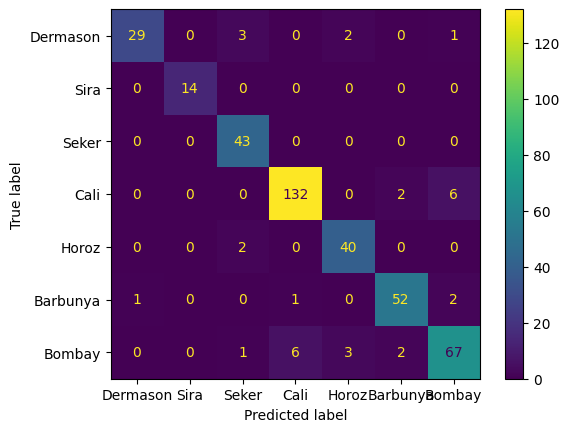

In [28]:
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score, f1_score, matthews_corrcoef, precision_recall_curve, classification_report
from sklearn.model_selection import StratifiedKFold

#data splitting to k-fold
skf = StratifiedKFold(n_splits=7)
skf.get_n_splits(X,y)


estimators = []
param_grid = {
    'n_estimators': [2,4,6,8,10,12,14,16,18,20,22,24,26,28,30,40,42,44,46,48,50,52,54,56]
    
}
clf = BaggingClassifier(model_3)

grid_search = GridSearchCV(clf,param_grid, scoring = 'balanced_accuracy',n_jobs = -1)
grid_search.fit(X_train_fold,y_train_fold)
bagged_3 = grid_search.best_estimator_

skf = StratifiedKFold(n_splits=7)
skf.get_n_splits(X,y)





for train_index, test_index in skf.split(X, y):
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]
    
bagged_3.fit(X_train_fold,y_train_fold)
y_pred = bagged_3.predict(X_test_fold)

    
    
    
bas = balanced_accuracy_score(y_test_fold,y_pred)
print(f'The balanced accuracy is {bas}')
print(f'The classification report is: {classification_report(y_pred,y_test_fold)}')

cm = confusion_matrix(y_test_fold,y_pred)
cm_show = ConfusionMatrixDisplay(cm,display_labels=['Dermason','Sira','Seker','Cali','Horoz','Barbunya','Bombay'])
cm_show.plot()
plt.show()




**ANSWER CELL**

The chosen model is the bagged_3 which utilises bagging the Decision Tree Classifier. It outperformed the other clasisfiers by a large amount. While both the bagged and non-bagged version of the Decision Tree did well, there was still around 1-2% improvement in balanced accuracy, however at a slight increase in computaional cost. It was able to achieve a balanced accuracy of roughly 92% to 93%, with a fairly consistent performance across all the classes, although a further improvement could be made to the Dermason and Bombay (index 0 and 6). The main choice for the bagged version of the model is the change in the individual metrics. It improved the 2 lowest metrics, the recall of class 2 and the precision of class 1. This means that the model will perform much more consistently and have less bias between classes. So while at first glance, the the summative metric improvement is not large, the improved consistency of performance across the classes warrants the use of the bagged version of the model. 
The Sira (index 1), had the best performance of 100% correct prediction with precision, recall and f1 score all being at 1. This is most likely the case as this class has the least amount of samples, therefore less chance of an error occuring since both the recall and precision are at 1, meaning that the model doesn't seem to favour it (in this case precision would be 1 but recall much smaller).
The area where to model seems to do the worst is precision, ie correctly identifying the class, although the recall (misclasifying as the class) is not far behind apart from class 1 where there is a significant difference between the preciion and recall score (0.83 vs 0.97), meaning the model tends to misclasify it as other classes. The Seker class (index 2), correctly identified the class at a precision of 1 and recall of 0.88, shows a small bias of the model towards predicting the class as class Seker, which could be improved slightly by balancing the 2 and bringing them closer together, in other words, a certain degree of error is always expected in the real world, therefore bringing down the precision score and increasing the recall score (decreasing the number of other beans being classified as Seker) would make the model more realistic and improve the performance.
Overall the model did very well with a high balanced accuracy score and no model should be expected to be 100% accurate in the real world, some errors are always expected and most model are considered good after 70% accuracy. The individual class metrics were relatively even across all classes with good performance on all of them, however, the model was slightly less precise at clssifying class 0 and class 6, while being correctly identifying all the entires belonging to class 1 and class 2, however with a small bias towards class 2 as the recall rate is at 0.89. 

## References

[1] Koklu, M. and Ozkan, I.A., 2020. Multiclass classification of dry beans using computer vision and machine learning techniques. _Computers and Electronics in Agriculture_, 174, p.105507.

[2] Murat Koklu: Dry Bean Dataset https://www.muratkoklu.com/datasets/ (accessed 14/08/2024)

[3] Mateen Ulhaq, Mike Hordecki (code) https://stackoverflow.com/a/522578/884412 (accessed 24/08/2023)

[4] Pazoki, A.R., Farokhi, F. and Pazoki, Z., 2014. Classification of rice grain varieties using two artificial neural networks (MLP and neuro-fuzzy).